In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
dataset_dir="/Users/shubhamshelar/Downloads/LP-IV-datasets 2/Object Detection(Ass6)/caltech-101-img"

datagen = ImageDataGenerator(rescale=1.0 / 255,)
dataset_generator=datagen.flow_from_directory(
    dataset_dir,
    target_size=(64, 64), #resizes the image into 64 by 64 pixel
    batch_size=2000, #Sets the batch size for training.
    class_mode='categorical' # labels are one-hot encoded
)


Found 9144 images belonging to 102 classes.


In [29]:
x_train, y_train =  dataset_generator[0]
x_test, y_test = dataset_generator[1]

print(len(x_train))
print(len(x_test))

2000
2000


In [12]:
from tensorflow.keras.applications import VGG16

path1="/Users/shubhamshelar/Downloads/LP-IV-datasets 2/Object Detection(Ass6)/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5"

# Load the pre-trained VGG16 model without the top (classification) layers
base_model = VGG16(weights=path1, include_top=False, input_shape=(64,64, 3))


In [13]:
for layer in base_model.layers:
    layer.trainable = False


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# Create a new model by adding custom classifier layers on top of the base VGG16 model
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dense(102, activation='softmax')  # Adjust num_classes for your dataset
])


In [16]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test))


Epoch 1/10


2023-11-15 23:49:38.924583: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


63/63 [==============================] - 35s 548ms/step - loss: 3.3555 - accuracy: 0.3070 - val_loss: 2.5902 - val_accuracy: 0.4375
Epoch 2/10
63/63 [==============================] - 38s 614ms/step - loss: 2.0317 - accuracy: 0.5435 - val_loss: 2.0384 - val_accuracy: 0.5300
Epoch 3/10
63/63 [==============================] - 42s 667ms/step - loss: 1.3560 - accuracy: 0.6915 - val_loss: 1.8056 - val_accuracy: 0.5860
Epoch 4/10
63/63 [==============================] - 42s 666ms/step - loss: 0.9425 - accuracy: 0.7805 - val_loss: 1.7050 - val_accuracy: 0.6000
Epoch 5/10
63/63 [==============================] - 42s 666ms/step - loss: 0.6559 - accuracy: 0.8640 - val_loss: 1.7719 - val_accuracy: 0.5750
Epoch 6/10
63/63 [==============================] - 42s 673ms/step - loss: 0.4619 - accuracy: 0.9170 - val_loss: 1.6679 - val_accuracy: 0.6065
Epoch 7/10
63/63 [==============================] - 43s 682ms/step - loss: 0.3319 - accuracy: 0.9430 - val_loss: 1.6298 - val_accuracy: 0.6115
Epoch 8/10

In [25]:
# Unfreeze some layers for fine-tuning
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Recompile the model with a lower learning rate for fine-tuning
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test))


Epoch 1/10
63/63 [==============================] - 42s 673ms/step - loss: 1.1109 - accuracy: 0.6845 - val_loss: 2.1906 - val_accuracy: 0.5420
Epoch 2/10
63/63 [==============================] - 48s 771ms/step - loss: 0.8047 - accuracy: 0.7600 - val_loss: 2.2692 - val_accuracy: 0.5460
Epoch 3/10
63/63 [==============================] - 61s 983ms/step - loss: 0.5343 - accuracy: 0.8400 - val_loss: 2.4642 - val_accuracy: 0.5645
Epoch 4/10
63/63 [==============================] - 67s 1s/step - loss: 0.3406 - accuracy: 0.8975 - val_loss: 2.9405 - val_accuracy: 0.5500
Epoch 5/10
63/63 [==============================] - 60s 965ms/step - loss: 0.2887 - accuracy: 0.9125 - val_loss: 2.9919 - val_accuracy: 0.5560
Epoch 6/10
63/63 [==============================] - 62s 989ms/step - loss: 0.1708 - accuracy: 0.9455 - val_loss: 3.2098 - val_accuracy: 0.5890
Epoch 7/10
63/63 [==============================] - 58s 930ms/step - loss: 0.1730 - accuracy: 0.9515 - val_loss: 3.1738 - val_accuracy: 0.5805
Ep

In [26]:

import numpy as np

# Get predictions for test data
predictions = model.predict(x_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)




63/63 [==============================] - 25s 396ms/step


In [27]:
from sklearn.metrics import classification_report

class_report = classification_report(true_classes, predicted_classes)
print(class_report)

              precision    recall  f1-score   support

           0       0.34      0.43      0.38       108
           1       0.95      0.96      0.96        84
           2       0.98      0.98      0.98       106
           3       0.84      0.78      0.81        41
           4       0.87      1.00      0.93       181
           5       0.35      0.73      0.47        11
           6       0.94      0.94      0.94       173
           7       0.67      0.20      0.31        10
           8       0.10      0.17      0.12         6
           9       0.03      0.17      0.06         6
          10       0.12      0.08      0.10        13
          11       0.00      0.00      0.00         7
          12       0.50      0.25      0.33         4
          13       0.60      0.53      0.56        34
          14       0.64      0.44      0.52        16
          15       0.30      0.23      0.26        13
          16       0.50      0.06      0.10        18
          17       0.10    

/Users/shubhamshelar/anaconda3/envs/ML/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/shubhamshelar/anaconda3/envs/ML/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/shubhamshelar/anaconda3/envs/ML/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_

Preditcted:  4
Actual:  4


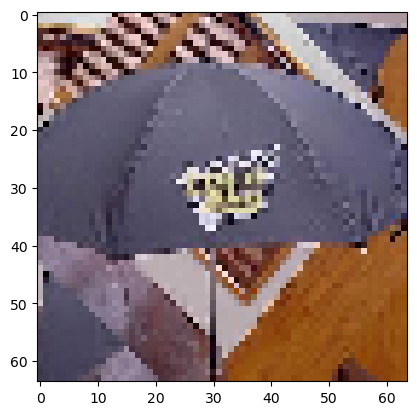

In [42]:
n = 987
# labels = list(dataset_generator.class_indices.keys())
import matplotlib.pyplot as plt
plt.imshow(x_test[n])
print("Preditcted: ",true_classes[n])
print("Actual: ",predicted_classes[n])